<!-- CODEx_DOC -->
# Name: Ansh Gajera
# Roll Number: 23AIML019
# Project Title: House Price Prediction


## Import Libraries

<!-- CODEx_DOC -->
### Step 1: Import Required Libraries

What this code is doing:
- Imports libraries for data handling, visualization, preprocessing, machine learning, and ANN modeling.
- Sets warning filters to keep notebook output clean.

Why this step is important:
- Establishes all tools needed for the full workflow in one place.
- Ensures later cells run consistently with required dependencies available.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import re
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


## Load Dataset

<!-- CODEx_DOC -->
### Step 2: Load Dataset Preview

What this code is doing:
- Reads `HouseData.csv` into a DataFrame.
- Displays the first few rows for a quick preview.

Why this step is important:
- Confirms data is loaded correctly.
- Gives an initial understanding of available columns and raw formatting.


In [4]:
df = pd.read_csv("HouseData.csv")
df.head()

,Unnamed: 0,district,price,address,AdUpdateDate,Category,GrossSquareMeters,BuildingAge,NumberFloorsofBuilding,UsingStatus,...,PriceStatus,RentalIncome,NumberOfBalconies,BalconyType,HallSquareMeters,WCSquareMeters,IsItVideoNavigable?,Subscription,BathroomSquareMeters,BalconySquareMeters
0,0,adalar,"3,100,000TL","['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",24 Şubat 2022,Satılık,160 m2,21 Ve Üzeri,3,Mülk Sahibi Oturuyor,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,adalar,"1,600,000TL","['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",02 Mart 2022,Satılık,120 m2,5-10,3,Mülk Sahibi Oturuyor,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,adalar,"18,500,000TL","['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...",11 Şubat 2022,Satılık,350 m2,21 Ve Üzeri,2,Mülk Sahibi Oturuyor,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,adalar,"9,500,000TL","['Anasayfa', 'Satılık Bina', 'İstanbul Satılık...",11 Şubat 2022,Satılık,550 m2,11-15,3,Mülk Sahibi Oturuyor,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,adalar,"25,000,000TL","['Anasayfa', 'Satılık Köşk', 'İstanbul Satılık...",19 Ocak 2022,Satılık,840 m2,21 Ve Üzeri,4,Boş,...,Genel Fiyat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 3: Check Dataset Size

What this code is doing:
- Prints the number of rows and columns in the dataset.

Why this step is important:
- Helps estimate dataset scale and complexity.
- Provides a baseline before cleaning and feature engineering.


In [5]:
print(df.shape)


(25155, 38)


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- Dataset size is `(25155, 38)`.

Interpretation:
- The project has enough samples for robust model training.
- Feature count is moderate but includes missing-data challenges.


## 2. EDA MODULE

<!-- CODEx_DOC -->
### Step 4: Generate Initial Summary Statistics

What this code is doing:
- Defines and runs a function to show numeric summary, categorical summary, and missing-value counts.

Why this step is important:
- Identifies data quality issues early.
- Highlights columns needing cleaning, conversion, or imputation.


In [6]:
def summary_statistics(df):
    print("Shape:", df.shape)
    display(df.describe())
    display(df.describe(include="object"))
    print("\nMissing Values:\n", df.isnull().sum().sort_values(ascending=False))

summary_statistics(df)

Shape: (25155, 38)


,Unnamed: 0,NumberFloorsofBuilding
count,25155.000000,25155.000000
mean,12577.000000,7.757782
std,7261.767347,6.952397
min,0.000000,1.000000
25%,6288.500000,4.000000
50%,12577.000000,5.000000
75%,18865.500000,8.000000
max,25154.000000,71.000000


,district,price,address,AdUpdateDate,Category,GrossSquareMeters,BuildingAge,UsingStatus,EligibilityForInvestment,BuildStatus,...,PriceStatus,RentalIncome,NumberOfBalconies,BalconyType,HallSquareMeters,WCSquareMeters,IsItVideoNavigable?,Subscription,BathroomSquareMeters,BalconySquareMeters
count,25155,25155,25155,25155,25155,25155,25155,25155,21506,11231,...,25155,5815,5324,4720,1433,865,5481,4488,1112,1040
unique,39,2825,1638,186,1,584,10,3,3,3,...,2,159,4,5,61,22,2,229,24,49
top,sariyer,"1,350,000TL","['Anasayfa', 'Satılık Residence', 'İstanbul Sa...",04 Mart 2022,Satılık,100 m2,0 (Yeni),Boş,Bilinmiyor,İkinci El,...,Genel Fiyat,3.000 TL,1,Açık Balkon,25 m2,5 m2,Hayır,50 TL,5 m2,5 m2
freq,1449,371,452,1605,25155,1478,7333,11139,12751,6409,...,24335,698,3485,3100,293,167,3413,998,243,156



Missing Values:
 WCSquareMeters              24290
BalconySquareMeters         24115
BathroomSquareMeters        24043
HallSquareMeters            23722
Subscription                20667
BalconyType                 20435
NumberOfBalconies           19831
IsItVideoNavigable?         19674
RentalIncome                19340
MortgageStatus              19097
NumberOfWCs                 17026
Balcony                     16046
TitleStatus                 15443
StructureType               14749
BuildStatus                 13924
ItemStatus                   6823
Swap                         4316
EligibilityForInvestment     3649
district                        0
Unnamed: 0                      0
address                         0
price                           0
Category                        0
AdUpdateDate                    0
NumberOfRooms                   0
FloorLocation                   0
HeatingType                     0
AdCreationDate                  0
NumberOfBathrooms             

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 5: Inspect Data Types

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [7]:
print("\nData Types:\n")
print(df.dtypes)


Data Types:

Unnamed: 0                   int64
district                    object
price                       object
address                     object
AdUpdateDate                object
Category                    object
GrossSquareMeters           object
BuildingAge                 object
NumberFloorsofBuilding       int64
UsingStatus                 object
EligibilityForInvestment    object
BuildStatus                 object
TitleStatus                 object
ItemStatus                  object
NumberOfBathrooms           object
NumberOfWCs                 object
AdCreationDate              object
Type                        object
NetSquareMeters             object
NumberOfRooms               object
FloorLocation               object
HeatingType                 object
CreditEligibility           object
InsideTheSite               object
StructureType               object
MortgageStatus              object
Swap                        object
Balcony                     object
PriceS

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 6: Visualize Missing Values

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


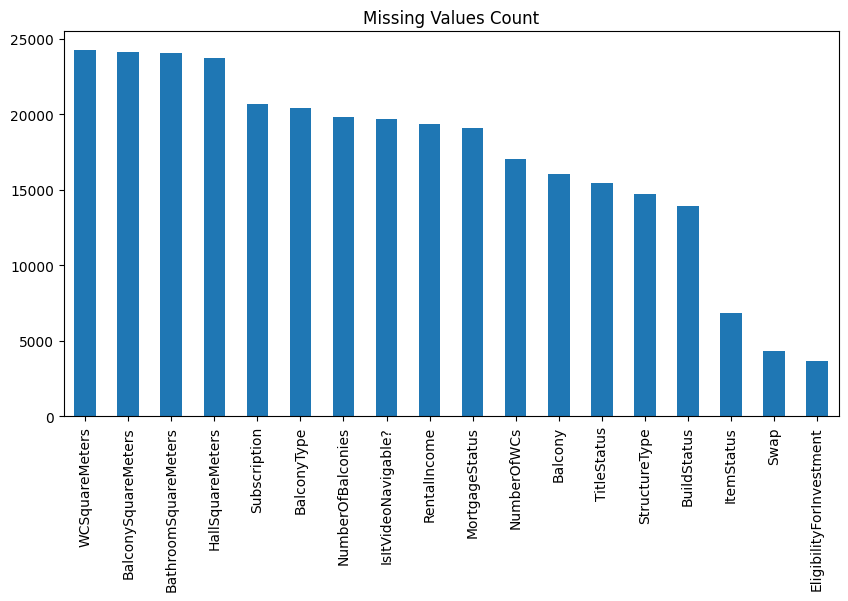

In [8]:
def plot_missing_values(df):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    plt.figure(figsize=(10,5))
    missing.plot(kind='bar')
    plt.title("Missing Values Count")
    plt.show()

plot_missing_values(df)

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 7: Build Missing-Value Table

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [9]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    "MissingCount": missing_count,
    "MissingPercent": missing_percent
}).sort_values(by="MissingPercent", ascending=False)

display(missing_df)

,MissingCount,MissingPercent
WCSquareMeters,24290,96.561320
BalconySquareMeters,24115,95.865633
BathroomSquareMeters,24043,95.579408
HallSquareMeters,23722,94.303319
Subscription,20667,82.158617
BalconyType,20435,81.236335
NumberOfBalconies,19831,78.835222
IsItVideoNavigable?,19674,78.211091
RentalIncome,19340,76.883323
MortgageStatus,19097,75.917313


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 8: Define High-Missing Column Removal Function

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


<!-- CODEx_DOC -->
### Step 7A: Function-Style EDA Plots (Added, Not Executed)

What this code is doing:
- Defines reusable EDA plotting functions for numeric distribution, categorical frequency, correlation heatmap, and price-vs-area scatter.
- Keeps all EDA logic modular so plots can be called with one function at a time.
- Does not execute plots automatically.

Why this step is important:
- Makes EDA cleaner, reusable, and report-friendly.
- Standardizes plot style and reduces repeated plotting code.
- Helps identify patterns, outliers, and feature relationships quickly.


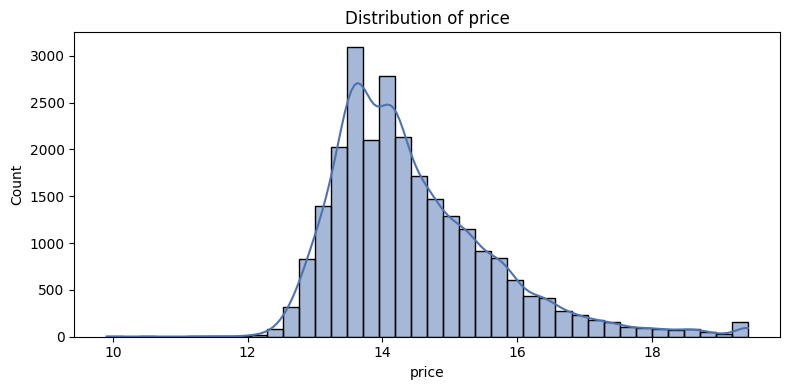

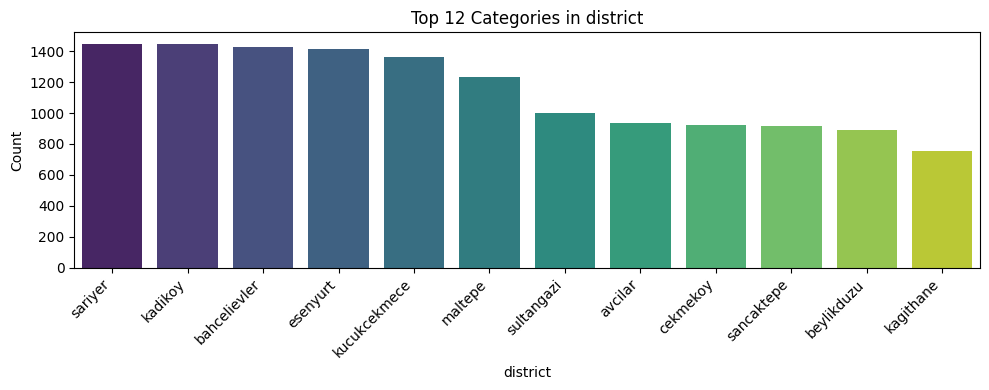

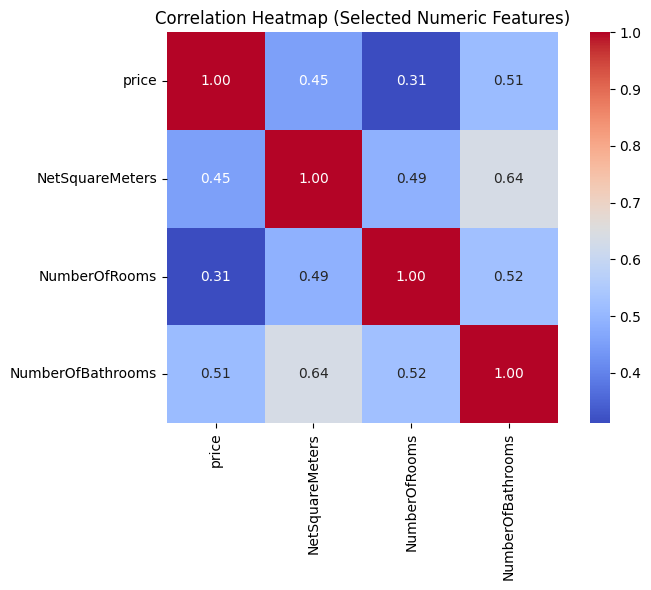

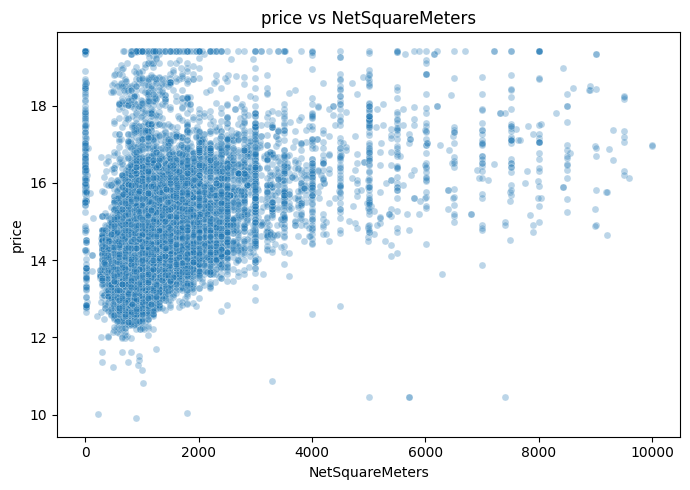

In [60]:
def plot_numeric_distribution(df, col, bins=40):
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), bins=bins, kde=True, color="#4C72B0")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


def plot_top_categories(df, col, top_n=10):
    vc = df[col].fillna("Missing").value_counts().head(top_n)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=vc.index, y=vc.values, palette="viridis")
    plt.title(f"Top {top_n} Categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df, cols):
    corr = df[cols].corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title("Correlation Heatmap (Selected Numeric Features)")
    plt.tight_layout()
    plt.show()


def plot_price_vs_area(df, x_col="NetSquareMeters", y_col="price"):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.3, s=25)
    plt.title(f"{y_col} vs {x_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()



plot_numeric_distribution(df, "price")
plot_top_categories(df, "district", top_n=12)
plot_correlation_heatmap(df, ["price", "NetSquareMeters", "NumberOfRooms", "NumberOfBathrooms"])
plot_price_vs_area(df, "NetSquareMeters", "price")


<!-- CODEx_DOC -->
### Step 7A.1: KDE and Skewness Plots (Added, Not Executed)

What this code is doing:
- Adds a reusable KDE plot function for selected numeric features.
- Adds a skewness bar-plot function to compare distribution asymmetry across numeric columns.
- Keeps example calls commented so nothing runs automatically.

Why this step is important:
- KDE gives a smooth view of feature distributions beyond histograms.
- Skewness plot helps decide where log transform or outlier treatment is needed.


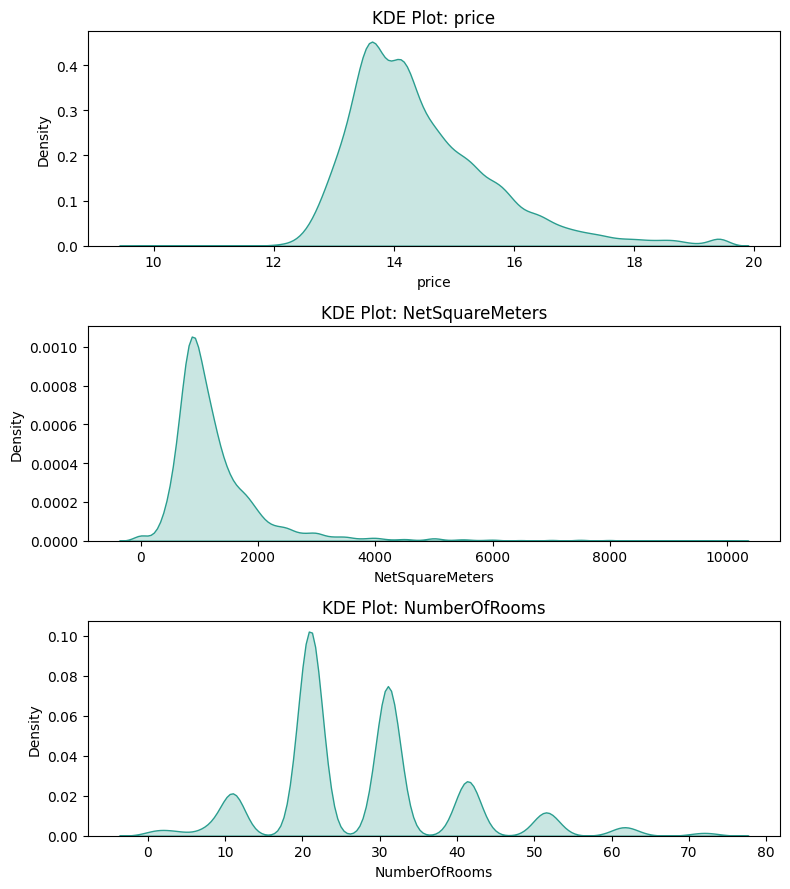

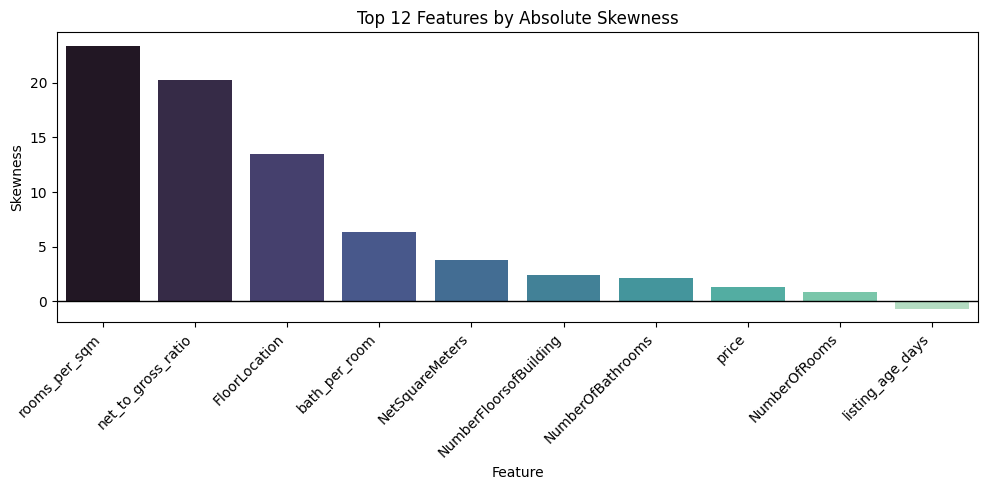

In [62]:
def plot_kde_features(df, cols, fill=True):
    valid_cols = [c for c in cols if c in df.columns]
    if not valid_cols:
        print("No valid columns found for KDE plot.")
        return

    n = len(valid_cols)
    fig, axes = plt.subplots(n, 1, figsize=(8, 3 * n), squeeze=False)
    for i, col in enumerate(valid_cols):
        sns.kdeplot(data=df, x=col, fill=fill, ax=axes[i, 0], color="#2A9D8F")
        axes[i, 0].set_title(f"KDE Plot: {col}")
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel("Density")
    plt.tight_layout()
    plt.show()


def plot_skewness_bar(df, top_n=15):
    num_df = df.select_dtypes(include=["number"])
    if num_df.empty:
        print("No numeric columns available for skewness plot.")
        return

    skew = num_df.skew(numeric_only=True).sort_values(key=lambda s: s.abs(), ascending=False)
    skew_top = skew.head(top_n)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=skew_top.index, y=skew_top.values, palette="mako")
    plt.axhline(0, color="black", linewidth=1)
    plt.title(f"Top {top_n} Features by Absolute Skewness")
    plt.xlabel("Feature")
    plt.ylabel("Skewness")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_kde_features(df, ["price", "NetSquareMeters", "NumberOfRooms"])
plot_skewness_bar(df, top_n=12)


<!-- CODEx_DOC -->
### Insights for KDE and Skewness Plots

How to interpret after running:
- KDE Plot: check whether distribution is symmetric, right-skewed, left-skewed, or multi-modal.
- Skewness Bar Plot: values far from 0 indicate high skewness and possible need for transformation.
- Strong positive skew in `price` usually supports clipping/log transform.
- Features with very high skew can also create instability in linear models if left untreated.


<!-- CODEx_DOC -->
### Insights for These EDA Functions

How to read these plots after you run them:
- `plot_numeric_distribution`:
  - Check whether the feature is skewed, symmetric, or multi-modal.
  - For `price`, strong right skew usually suggests transformation/outlier handling.
- `plot_top_categories`:
  - Identifies dominant categories and class imbalance.
  - Very rare categories may need grouping to reduce noise.
- `plot_correlation_heatmap`:
  - Highlights strong positive/negative relationships.
  - Very high absolute correlation between predictors can indicate multicollinearity.
- `plot_price_vs_area`:
  - Shows whether larger area generally maps to higher price.
  - Look for spread widening at high area values (heteroscedasticity) and visible outliers.


<!-- CODEx_DOC -->
### Step 7B: Missing-Value (NA) Diagnostics and Handling Function (Added, Not Executed)

What this code is doing:
- Builds a reusable function to summarize missing values in count and percent.
- Imputes numeric NA with median and categorical NA with `"Missing"` (optional).
- Returns both the cleaned DataFrame and NA summary table.

Why this step is important:
- Directly addresses NA issues in a controlled, reusable way.
- Prevents training/evaluation failures caused by missing values.
- Keeps NA treatment transparent for report documentation.


In [61]:
def handle_missing_values_report(df, numeric_strategy="median", categorical_fill="Missing"):
    na_count = df.isna().sum()
    na_percent = (na_count / len(df)) * 100
    na_report = pd.DataFrame({
        "MissingCount": na_count,
        "MissingPercent": na_percent
    }).sort_values("MissingPercent", ascending=False)

    cleaned = df.copy()

    num_cols = cleaned.select_dtypes(include=["number"]).columns
    cat_cols = cleaned.select_dtypes(include=["object"]).columns

    if numeric_strategy == "median":
        for col in num_cols:
            if cleaned[col].isna().any():
                cleaned[col] = cleaned[col].fillna(cleaned[col].median())

    for col in cat_cols:
        if cleaned[col].isna().any():
            cleaned[col] = cleaned[col].fillna(categorical_fill)

    return cleaned, na_report


df_clean_preview, na_report = handle_missing_values_report(df)
display(na_report.head(15))


,MissingCount,MissingPercent
district,0,0.0
price,0,0.0
Category,0,0.0
NumberFloorsofBuilding,0,0.0
UsingStatus,0,0.0
EligibilityForInvestment,0,0.0
BuildStatus,0,0.0
TitleStatus,0,0.0
ItemStatus,0,0.0
NumberOfBathrooms,0,0.0


<!-- CODEx_DOC -->
### Insights for NA-Handling Function

Interpretation notes:
- Use `na_report` to identify which columns are the main source of missingness.
- Median imputation is robust for skewed numeric variables.
- Categorical fill keeps rows intact while preserving missingness information.
- For extremely high missingness columns, dropping them may be better than imputing.


In [10]:


def drop_high_missing(df, threshold=80):
    """
    Drops columns with missing percentage above threshold.
    """
    missing_percent = df.isnull().mean() * 100
    cols_to_drop = missing_percent[missing_percent > threshold].index.tolist()

    print(f"Dropping {len(cols_to_drop)} columns:")
    print(cols_to_drop)

    return df.drop(columns=cols_to_drop), cols_to_drop



<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 9: Define Price Cleaning Function

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [11]:


def clean_price_column(df, target_col="price"):
    """
    Cleans price column by removing non-numeric characters.
    """
    df[target_col] = (
        df[target_col]
        .astype(str)
        .str.replace(r"[^\d]", "", regex=True)
    )

    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

    print("Null values in price after cleaning:", df[target_col].isnull().sum())

    return df

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 10: Define Numeric-Like Conversion Function

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [12]:


def convert_numeric_like_columns(df):
    """
    Converts object columns that contain numeric values into numeric dtype.
    """
    for col in df.select_dtypes(include="object").columns:

        cleaned = df[col].astype(str).str.replace(r"[^\d\.]", "", regex=True)

        # Try converting — only if conversion is meaningful
        converted = pd.to_numeric(cleaned, errors="coerce")

        # If at least 60% values become numeric → accept conversion
        if converted.notnull().mean() > 0.6:
            df[col] = converted

    return df

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 11: Execute Core Cleaning Pipeline

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [13]:
# 1. Drop ultra high missing columns
df, dropped_cols = drop_high_missing(df, threshold=80)

# 2. Clean price
df = clean_price_column(df, target_col="price")

# 3. Convert numeric-like columns
df = convert_numeric_like_columns(df)

print("\nUpdated Shape:", df.shape)
print("\nUpdated Data Types:\n")
print(df.dtypes)

Dropping 6 columns:
['BalconyType', 'HallSquareMeters', 'WCSquareMeters', 'Subscription', 'BathroomSquareMeters', 'BalconySquareMeters']
Null values in price after cleaning: 0

Updated Shape: (25155, 32)

Updated Data Types:

Unnamed: 0                    int64
district                     object
price                         int64
address                      object
AdUpdateDate                  int64
Category                     object
GrossSquareMeters           float64
BuildingAge                   int64
NumberFloorsofBuilding        int64
UsingStatus                  object
EligibilityForInvestment     object
BuildStatus                  object
TitleStatus                  object
ItemStatus                   object
NumberOfBathrooms           float64
NumberOfWCs                  object
AdCreationDate                int64
Type                         object
NetSquareMeters             float64
NumberOfRooms               float64
FloorLocation               float64
HeatingType       

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 12: Post-Cleaning Validation Report

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [14]:
def post_cleaning_report(df):

    print("Dataset Shape:", df.shape)

    print("\nRemaining Missing %:")
    display((df.isnull().mean() * 100).sort_values(ascending=False))

    print("\nNumeric Columns:")
    display(df.select_dtypes(include="number").columns)

    print("\nCategorical Columns:")
    display(df.select_dtypes(include="object").columns)

    print("\nTarget Summary:")
    display(df["price"].describe())
    print("Target Skewness:", df["price"].skew())

post_cleaning_report(df)

Dataset Shape: (25155, 32)

Remaining Missing %:


NumberOfBalconies           78.835222
IsItVideoNavigable?         78.211091
RentalIncome                76.883323
MortgageStatus              75.917313
NumberOfWCs                 67.684357
Balcony                     63.788511
TitleStatus                 61.391373
StructureType               58.632479
BuildStatus                 55.352813
FloorLocation               29.051878
ItemStatus                  27.123832
Swap                        17.157623
EligibilityForInvestment    14.506062
NumberOfRooms                1.045518
NumberOfBathrooms            0.993838
Unnamed: 0                   0.000000
UsingStatus                  0.000000
NumberFloorsofBuilding       0.000000
price                        0.000000
address                      0.000000
AdUpdateDate                 0.000000
Category                     0.000000
GrossSquareMeters            0.000000
BuildingAge                  0.000000
district                     0.000000
CreditEligibility            0.000000
InsideTheSit


Numeric Columns:


Index(['Unnamed: 0', 'price', 'AdUpdateDate', 'GrossSquareMeters',
       'BuildingAge', 'NumberFloorsofBuilding', 'NumberOfBathrooms',
       'AdCreationDate', 'NetSquareMeters', 'NumberOfRooms', 'FloorLocation'],
      dtype='object')


Categorical Columns:


Index(['district', 'address', 'Category', 'UsingStatus',
       'EligibilityForInvestment', 'BuildStatus', 'TitleStatus', 'ItemStatus',
       'NumberOfWCs', 'Type', 'HeatingType', 'CreditEligibility',
       'InsideTheSite', 'StructureType', 'MortgageStatus', 'Swap', 'Balcony',
       'PriceStatus', 'RentalIncome', 'NumberOfBalconies',
       'IsItVideoNavigable?'],
      dtype='object')


Target Summary:


count    2.515500e+04
mean     1.287062e+07
std      2.916856e+08
min      2.000000e+04
25%      8.000000e+05
50%      1.450000e+06
75%      3.500000e+06
max      3.850000e+10
Name: price, dtype: float64

Target Skewness: 101.33404207057154


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 13: Remove Obvious Leakage/Noise Columns

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [15]:
def remove_leakage_columns(df):

    leakage_cols = [
        "Unnamed: 0",   # index
        "address"       # high-cardinality noise
    ]

    existing = [col for col in leakage_cols if col in df.columns]

    print("Removing:", existing)

    return df.drop(columns=existing)

df = remove_leakage_columns(df)

print("New shape:", df.shape)

Removing: ['Unnamed: 0', 'address']
New shape: (25155, 30)


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 14: Analyze Target Outliers

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [16]:
def analyze_target_outliers(df, target="price"):

    print("Top 10 highest prices:")
    display(df[target].sort_values(ascending=False).head(10))

    print("\nPercentiles:")
    percentiles = df[target].quantile([0.90, 0.95, 0.99, 0.995, 0.999])
    display(percentiles)

analyze_target_outliers(df)

Top 10 highest prices:


24876    38500000016
15230    16000000000
5343      9500000018
20321     7500000002
20564     6850000027
17854     4875000027
5347      4375000032
6917      3750000017
5521      3600000090
5556      3375000100
Name: price, dtype: int64


Percentiles:


0.900    9.000004e+06
0.950    1.950000e+07
0.990    1.300000e+08
0.995    2.734600e+08
0.999    1.626900e+09
Name: price, dtype: float64

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 15: Stabilize Target Distribution

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [17]:
def stabilize_target(df, target="price", upper_quantile=0.995):

    upper_limit = df[target].quantile(upper_quantile)

    print("Upper clipping at:", upper_limit)

    df[target] = df[target].clip(upper=upper_limit)

    print("Skew before log:", df[target].skew())

    df[target] = np.log1p(df[target])

    print("Skew after log:", df[target].skew())

    return df

df = stabilize_target(df, target="price")

Upper clipping at: 273460002.0699991
Skew before log: 8.298615056589204
Skew after log: 1.2728839087319324


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- Clipping threshold used: `273460002.0699991`.
- Skewness dropped from `8.2986` to `1.2729` after log transform.

Interpretation:
- Target distribution became much more balanced.
- This should help models learn more stable patterns.


<!-- CODEx_DOC -->
### Step 16: Drop Remaining Very-High-Missing Features

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [18]:
def drop_very_high_missing(df, threshold=75):

    missing_percent = df.isnull().mean() * 100
    cols_to_drop = missing_percent[missing_percent > threshold].index.tolist()

    print("Dropping:", cols_to_drop)

    return df.drop(columns=cols_to_drop)

df = drop_very_high_missing(df, threshold=75)

print("Shape after drop:", df.shape)

Dropping: ['MortgageStatus', 'RentalIncome', 'NumberOfBalconies', 'IsItVideoNavigable?']
Shape after drop: (25155, 26)


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 17: Encode Missing Categorical Values

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [19]:

def encode_missing_as_category(df):

    cat_cols = df.select_dtypes(include="object").columns

    for col in cat_cols:
        if df[col].isnull().mean() > 0:
            df[col] = df[col].fillna("Missing")

    return df

df = encode_missing_as_category(df)

print("Remaining Missing %:")
print((df.isnull().mean() * 100).sort_values(ascending=False).head())

Remaining Missing %:
FloorLocation        29.051878
NumberOfRooms         1.045518
NumberOfBathrooms     0.993838
AdUpdateDate          0.000000
GrossSquareMeters     0.000000
dtype: float64


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 18: Engineer Date-Based Feature

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [20]:
def engineer_date_features(df):

    date_cols = ["AdCreationDate", "AdUpdateDate"]

    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    if "AdCreationDate" in df.columns:
        df["listing_age_days"] = (
            df["AdUpdateDate"] - df["AdCreationDate"]
        ).dt.days

    # Drop original date columns (avoid leakage)
    df = df.drop(columns=[c for c in date_cols if c in df.columns])

    return df

df = engineer_date_features(df)
print("Final Shape:", df.shape)

Final Shape: (25155, 25)


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 19: Impute Numeric Missing Values

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [21]:
def handle_numeric_missing(df):

    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    numeric_cols.remove("price")  # never touch target

    for col in numeric_cols:
        if df[col].isnull().mean() > 0:
            print(f"Imputing {col} with median")
            df[col] = df[col].fillna(df[col].median())

    return df

df = handle_numeric_missing(df)

print("Remaining Missing %:")
print((df.isnull().mean()*100).sort_values(ascending=False).head())

Imputing NumberOfBathrooms with median
Imputing NumberOfRooms with median
Imputing FloorLocation with median
Remaining Missing %:
district             0.0
price                0.0
Category             0.0
GrossSquareMeters    0.0
BuildingAge          0.0
dtype: float64


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 20: Check Multicollinearity

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [22]:
def check_multicollinearity(df, threshold=0.85):

    num_df = df.select_dtypes(include="number").drop(columns=["price"])

    corr_matrix = num_df.corr().abs()

    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    high_corr_pairs = [
        (col, row, upper.loc[row, col])
        for col in upper.columns
        for row in upper.index
        if upper.loc[row, col] > threshold
    ]

    print("Highly correlated pairs:")
    for pair in high_corr_pairs:
        print(pair)

check_multicollinearity(df)

Highly correlated pairs:
('NetSquareMeters', 'GrossSquareMeters', np.float64(0.8605310584624626))


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 21: Engineer Area-Based Features

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [23]:
def engineer_area_features(df):

    # Ratio feature
    df["net_to_gross_ratio"] = df["NetSquareMeters"] / (df["GrossSquareMeters"] + 1)

    # Price per sqm (use exp because target is log)
    df["price_per_sqm"] = np.expm1(df["price"]) / (df["NetSquareMeters"] + 1)

    # Drop one of the correlated area columns (optional for linear stability)
    df = df.drop(columns=["GrossSquareMeters"])

    return df

df = engineer_area_features(df)

print("Shape after area engineering:", df.shape)

Shape after area engineering: (25155, 26)


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 22: Engineer Density Features

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [24]:
def engineer_density_features(df):

    df["rooms_per_sqm"] = df["NumberOfRooms"] / (df["NetSquareMeters"] + 1)
    df["bath_per_room"] = df["NumberOfBathrooms"] / (df["NumberOfRooms"] + 1)

    return df

df = engineer_density_features(df)

print("Shape after density features:", df.shape)

Shape after density features: (25155, 28)


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 23: Remove Engineered Leakage Feature

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [25]:

def remove_leakage_features(df):

    leakage_cols = ["price_per_sqm"]

    existing = [col for col in leakage_cols if col in df.columns]

    if existing:
        print("Removing leakage features:", existing)
        df = df.drop(columns=existing)

    return df

df = remove_leakage_features(df)

Removing leakage features: ['price_per_sqm']


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 24: Create Feature Groups

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [26]:
def get_feature_groups(df, target="price"):

    X = df.drop(columns=[target])
    y = df[target]

    numeric_features = X.select_dtypes(include="number").columns.tolist()
    categorical_features = X.select_dtypes(include="object").columns.tolist()

    print("Numeric Features:", len(numeric_features))
    print(numeric_features)

    print("\nCategorical Features:", len(categorical_features))
    print(categorical_features)

    return X, y, numeric_features, categorical_features

X, y, numeric_features, categorical_features = get_feature_groups(df)

Numeric Features: 10
['BuildingAge', 'NumberFloorsofBuilding', 'NumberOfBathrooms', 'NetSquareMeters', 'NumberOfRooms', 'FloorLocation', 'listing_age_days', 'net_to_gross_ratio', 'rooms_per_sqm', 'bath_per_room']

Categorical Features: 16
['district', 'Category', 'UsingStatus', 'EligibilityForInvestment', 'BuildStatus', 'TitleStatus', 'ItemStatus', 'NumberOfWCs', 'Type', 'HeatingType', 'CreditEligibility', 'InsideTheSite', 'StructureType', 'Swap', 'Balcony', 'PriceStatus']


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 25: Measure Numeric Feature Strength

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [27]:
def numeric_feature_strength(df, target="price"):

    corr = df[numeric_features + [target]].corr()[target]
    corr = corr.drop(target).sort_values(ascending=False)

    print("Top Positive Correlations:")
    display(corr.head(10))

    print("\nTop Negative Correlations:")
    display(corr.tail(10))

    return corr

numeric_corr = numeric_feature_strength(df)

Top Positive Correlations:


NumberOfBathrooms         0.512716
NetSquareMeters           0.451828
NumberOfRooms             0.311389
bath_per_room             0.244137
NumberFloorsofBuilding    0.217104
net_to_gross_ratio        0.112388
rooms_per_sqm             0.102524
FloorLocation             0.096844
BuildingAge               0.027349
listing_age_days         -0.035541
Name: price, dtype: float64


Top Negative Correlations:


NumberOfBathrooms         0.512716
NetSquareMeters           0.451828
NumberOfRooms             0.311389
bath_per_room             0.244137
NumberFloorsofBuilding    0.217104
net_to_gross_ratio        0.112388
rooms_per_sqm             0.102524
FloorLocation             0.096844
BuildingAge               0.027349
listing_age_days         -0.035541
Name: price, dtype: float64

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 26: Plot Top Numeric Features vs Target

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


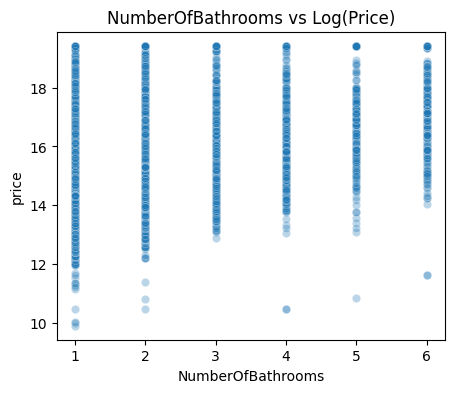

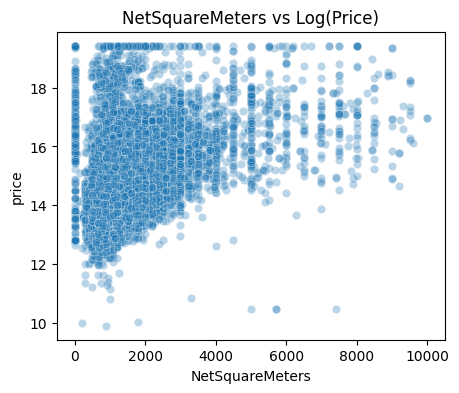

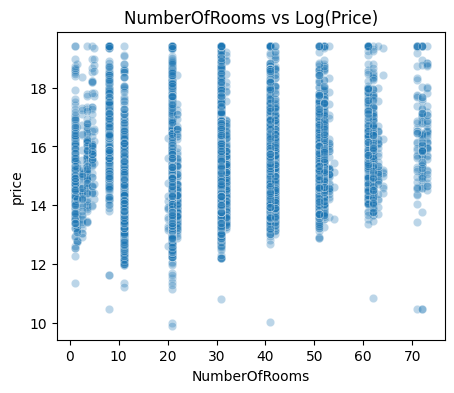

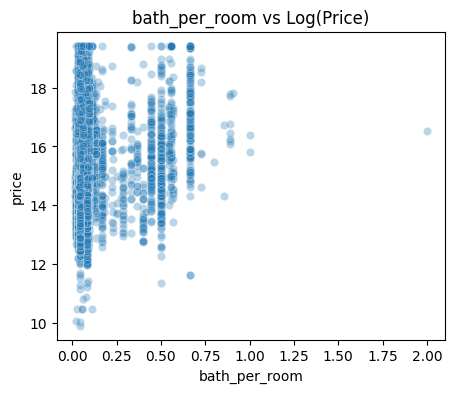

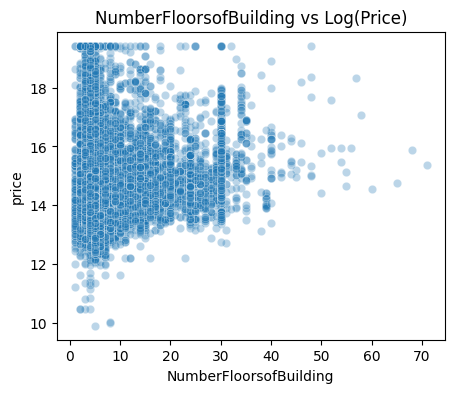

In [28]:
def plot_top_numeric_features(df, corr_series, top_n=5):

    top_features = corr_series.head(top_n).index.tolist()

    for col in top_features:
        plt.figure(figsize=(5,4))
        sns.scatterplot(x=df[col], y=df["price"], alpha=0.3)
        plt.title(f"{col} vs Log(Price)")
        plt.show()

plot_top_numeric_features(df, numeric_corr, top_n=5)

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 27: Remove Weak Numeric Features

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [29]:
def remove_weak_numeric_features(df, corr_series, threshold=0.03):

    weak_features = corr_series[abs(corr_series) < threshold].index.tolist()

    print("Removing weak numeric features:", weak_features)

    df = df.drop(columns=weak_features)

    return df

df = remove_weak_numeric_features(df, numeric_corr, threshold=0.03)

print("Remaining Numeric Features:", numeric_features)

Removing weak numeric features: ['BuildingAge']
Remaining Numeric Features: ['BuildingAge', 'NumberFloorsofBuilding', 'NumberOfBathrooms', 'NetSquareMeters', 'NumberOfRooms', 'FloorLocation', 'listing_age_days', 'net_to_gross_ratio', 'rooms_per_sqm', 'bath_per_room']


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 28: Verify Final Feature Set

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [30]:
df.columns

Index(['district', 'price', 'Category', 'NumberFloorsofBuilding',
       'UsingStatus', 'EligibilityForInvestment', 'BuildStatus', 'TitleStatus',
       'ItemStatus', 'NumberOfBathrooms', 'NumberOfWCs', 'Type',
       'NetSquareMeters', 'NumberOfRooms', 'FloorLocation', 'HeatingType',
       'CreditEligibility', 'InsideTheSite', 'StructureType', 'Swap',
       'Balcony', 'PriceStatus', 'listing_age_days', 'net_to_gross_ratio',
       'rooms_per_sqm', 'bath_per_room'],
      dtype='object')

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 29: Build Preprocessing Pipeline

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [31]:
def build_preprocessor(numeric_features, categorical_features):

    numeric_pipeline = Pipeline([
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    return preprocessor

preprocessor = build_preprocessor(numeric_features, categorical_features)

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 30: Define Cross-Validation Evaluation Function

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [32]:
def evaluate_model_cv(model, X, y, preprocessor, cv_splits=5):

    pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)

    rmse_scores = -cross_val_score(
        pipeline,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=kf,
        n_jobs=-1
    )

    r2_scores = cross_val_score(
        pipeline,
        X,
        y,
        scoring="r2",
        cv=kf,
        n_jobs=-1
    )

    return {
        "RMSE_mean": rmse_scores.mean(),
        "RMSE_std": rmse_scores.std(),
        "R2_mean": r2_scores.mean()
    }

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 31: Train and Compare Baseline Models

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [33]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    results[name] = evaluate_model_cv(model, X, y, preprocessor)

results_df = pd.DataFrame(results).T.sort_values("RMSE_mean")

results_df

Training LinearRegression...
Training Ridge...
Training Lasso...
Training DecisionTree...
Training RandomForest...
Training GradientBoosting...


,RMSE_mean,RMSE_std,R2_mean
RandomForest,0.800787,0.012969,0.564928
GradientBoosting,0.811480,0.018565,0.553151
Ridge,0.838459,0.019232,0.522955
LinearRegression,0.838622,0.019326,0.522768
DecisionTree,1.111426,0.019939,0.161331
Lasso,1.214405,0.012919,-0.000073


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- Baseline ranking by RMSE (lower is better):
- `RandomForest` RMSE `0.800787`, R² `0.564928` (best).
- `GradientBoosting` RMSE `0.811480`, R² `0.553151`.
- `Ridge` RMSE `0.838459`, R² `0.522955`.
- `LinearRegression` RMSE `0.838622`, R² `0.522768`.
- `DecisionTree` RMSE `1.111426`, R² `0.161331`.
- `Lasso` RMSE `1.214405`, R² `-0.000073`.

Interpretation:
- Ensemble methods clearly outperform linear and single-tree baselines.


<!-- CODEx_DOC -->
### Step 32: Visualize Baseline Model RMSE

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


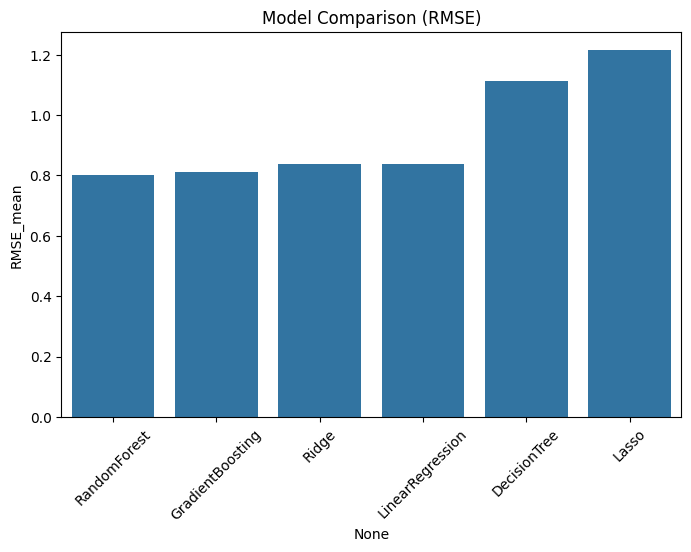

,RMSE_mean,RMSE_std,R2_mean
RandomForest,0.800787,0.012969,0.564928
GradientBoosting,0.811480,0.018565,0.553151
Ridge,0.838459,0.019232,0.522955
LinearRegression,0.838622,0.019326,0.522768
DecisionTree,1.111426,0.019939,0.161331
Lasso,1.214405,0.012919,-0.000073


In [34]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=results_df.index,
    y=results_df["RMSE_mean"]
)
plt.xticks(rotation=45)
plt.title("Model Comparison (RMSE)")
plt.show()

results_df

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 33: Hyperparameter Tuning for Random Forest

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [35]:
## RANDOM FOREST TUNING


from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", rf)
])

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=15,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X, y)

print("Best RF Params:", rf_search.best_params_)
print("Best RF RMSE:", -rf_search.best_score_)

Best RF Params: {'model__n_estimators': 600, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 20}
Best RF RMSE: 0.9011446741072607


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 34: Hyperparameter Tuning for Gradient Boosting

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [36]:
gb = GradientBoostingRegressor(random_state=42)

gb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5]
}

gb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", gb)
])

gb_search = RandomizedSearchCV(
    gb_pipeline,
    gb_param_grid,
    n_iter=10,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X, y)

print("Best GB Params:", gb_search.best_params_)
print("Best GB RMSE:", -gb_search.best_score_)

Best GB Params: {'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.1}
Best GB RMSE: 0.891099850543492


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 35: Summarize Tuned Model RMSE

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [37]:

tuned_results = {
    "RandomForest_Tuned": -rf_search.best_score_,
    "GradientBoosting_Tuned": -gb_search.best_score_
}

pd.DataFrame.from_dict(tuned_results, orient="index", columns=["RMSE"])

,RMSE
RandomForest_Tuned,0.901145
GradientBoosting_Tuned,0.891100


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 36: Transform Features for ANN Input

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [38]:
X_processed = preprocessor.fit_transform(X)

print("Processed shape:", X_processed.shape)

Processed shape: (25155, 116)


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 37: Create ANN Train-Test Split

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [39]:
X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train_ann.shape)
print("Test shape:", X_test_ann.shape)

Train shape: (20124, 116)
Test shape: (5031, 116)


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 38: Define ANN Architecture

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [44]:
def build_ann(input_dim, optimizer):
    
    model = Sequential([
        Dense(256, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(
        optimizer=optimizer,
        loss='mae',
        metrics=['r2_score']
    )
    
    return model

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 39: Train ANN with Adam Optimizer

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [45]:
## TRAIN ANN (ADAM)


ann_adam = build_ann(X_train_ann.shape[1], Adam(learning_rate=0.001))

history_adam = ann_adam.fit(
    X_train_ann,
    y_train_ann,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    verbose=1
)

Epoch 1/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.9394 - r2_score: -6.1250 - val_loss: 0.8033 - val_r2_score: 0.0946
Epoch 2/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0753 - r2_score: -0.3799 - val_loss: 1.8844 - val_r2_score: -1.9459
Epoch 3/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9731 - r2_score: -0.1622 - val_loss: 1.9566 - val_r2_score: -2.1343
Epoch 4/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9166 - r2_score: -0.0574 - val_loss: 2.6207 - val_r2_score: -4.2520
Epoch 5/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8640 - r2_score: 0.0574 - val_loss: 3.1507 - val_r2_score: -6.3592
Epoch 6/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8108 - r2_score: 0.1306 - val_loss: 2.6899 - val_r2_score: -4.4965
Epoch 7/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7589 - r2_score: 0.2104 - val_loss: 2.1655 - val_r2_score: -2.7311
Epoch 8/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7173 - r2_score: 0.2807 - val_lo

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 40: Train ANN with SGD Optimizer

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [47]:
## TRAIN ANN (SGD)

ann_sgd = build_ann(X_train_ann.shape[1], SGD(learning_rate=0.001, momentum=0.9))

history_sgd = ann_sgd.fit(
    X_train_ann,
    y_train_ann,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
504/504 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.1675 - r2_score: -9.2352 - val_loss: 0.9435 - val_r2_score: -0.1211
Epoch 2/100
504/504 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9014 - r2_score: -0.0609 - val_loss: 0.9267 - val_r2_score: -0.1004
Epoch 3/100
504/504 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7154 - r2_score: 0.2569 - val_loss: 1.2963 - val_r2_score: -0.7271
Epoch 4/100
504/504 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6277 - r2_score: 0.3636 - val_loss: 0.7089 - val_r2_score: 0.1923
Epoch 5/100
504/504 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5957 - r2_score: 0.3998 - val_loss: 0.6780 - val_r2_score: 0.2290
Epoch 6/100
504/504 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5818 - r2_score: 0.4196 - val_loss: 0.5436 - val_r2_score: 0.4889
Epoch 7/100
504/504 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5637 - r2_score: 0.4409 - val_loss: 0.7127 - val_r2_score: 0.2017
Epoch 8/100
504/504 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5539 - r2_score: 0.4486 - val

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 41: Evaluate ANN Models on Test Set

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [49]:
def evaluate_ann(model, X_test, y_test):
    
    y_pred = model.predict(X_test).flatten()
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    return rmse, r2

adam_rmse, adam_r2 = evaluate_ann(ann_adam, X_test_ann, y_test_ann)
sgd_rmse, sgd_r2 = evaluate_ann(ann_sgd, X_test_ann, y_test_ann)

print("ANN Adam -> RMSE:", adam_rmse, "R2:", adam_r2)
print("ANN SGD  -> RMSE:", sgd_rmse, "R2:", sgd_r2)

158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ANN Adam -> RMSE: 0.8634105175902307 R2: 0.513424234645002
ANN SGD  -> RMSE: 0.8666301776609362 R2: 0.5097885839902598


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- `ANN Adam` test RMSE: `0.8634105175902307`, R²: `0.513424234645002`.
- `ANN SGD` test RMSE: `0.8666301776609362`, R²: `0.5097885839902598`.

Interpretation:
- On hold-out test data, Adam performs slightly better than SGD.


<!-- CODEx_DOC -->
### Step 42: Plot Validation Loss Comparison

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


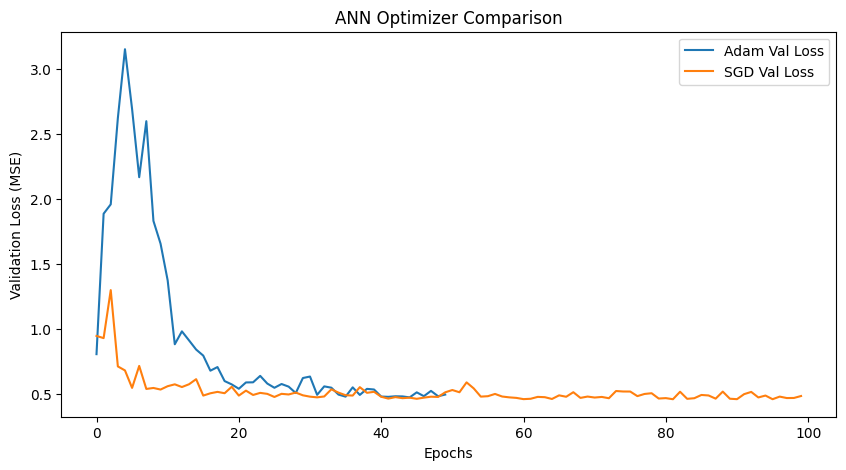

In [53]:

plt.figure(figsize=(10,5))

plt.plot(history_adam.history['val_loss'], label='Adam Val Loss')
plt.plot(history_sgd.history['val_loss'], label='SGD Val Loss')

plt.xlabel("Epochs")
plt.ylabel("Validation Loss (MSE)")
plt.legend()
plt.title("ANN Optimizer Comparison")
plt.show()

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 43: Plot Validation R² Comparison

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


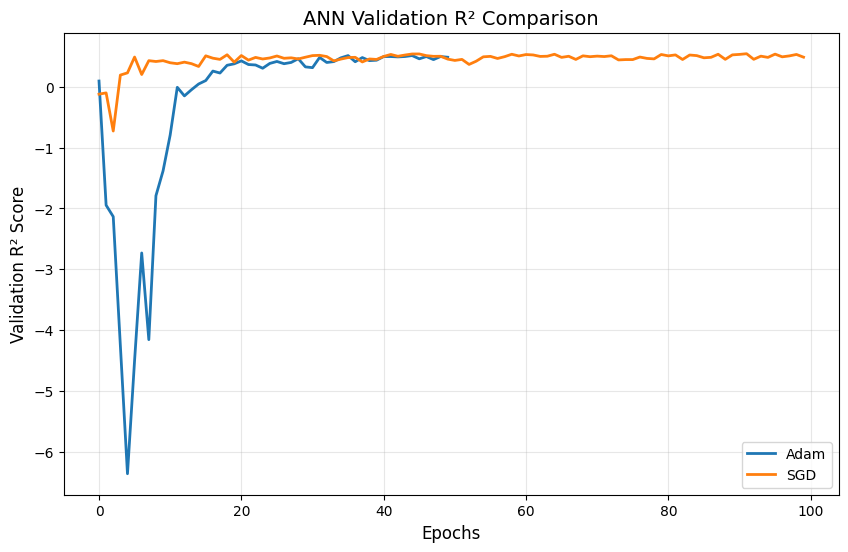

In [56]:
plt.figure(figsize=(10,6))

plt.plot(history_adam.history['val_r2_score'], 
         label='Adam', linewidth=2)

plt.plot(history_sgd.history['val_r2_score'], 
         label='SGD', linewidth=2)

plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Validation R² Score", fontsize=12)
plt.title("ANN Validation R² Comparison", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 44: Summarize ANN Test Metrics

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


In [57]:
ann_results = pd.DataFrame({
    "Model": ["ANN_Adam", "ANN_SGD"],
    "RMSE": [adam_rmse, sgd_rmse],
    "R2": [adam_r2, sgd_r2]
})

ann_results

,Model,RMSE,R2
0,ANN_Adam,0.863411,0.513424
1,ANN_SGD,0.866630,0.509789


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 45: Visualize ANN Architecture

What this code is doing:
- Executes the corresponding processing step in the workflow.

Why this step is important:
- Contributes to data preparation, modeling, or evaluation pipeline continuity.


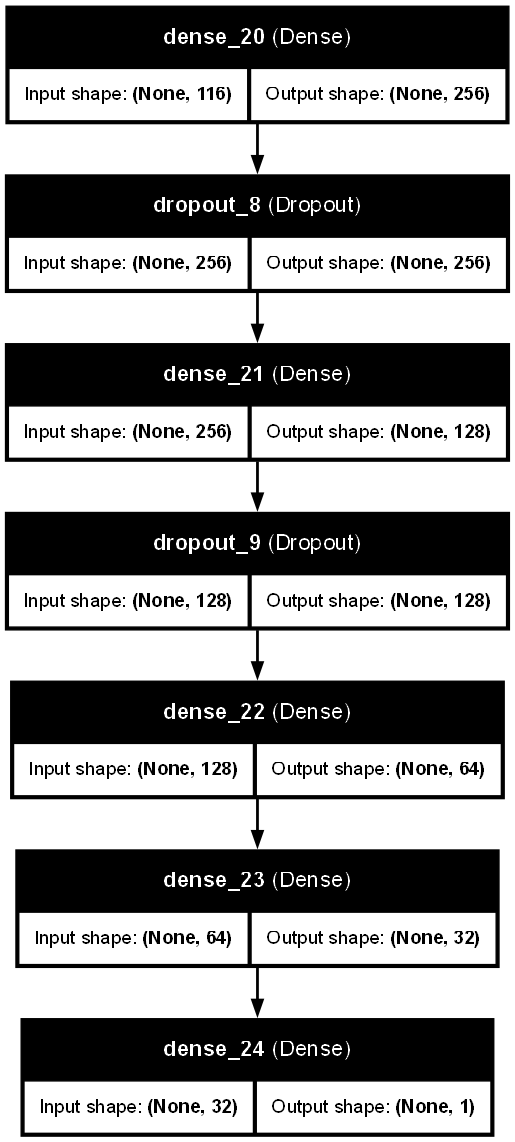

In [59]:
from tensorflow.keras.utils import plot_model
plot_model(
    ann_sgd,
    to_file="ann_sgd_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=100
)


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
### Step 46: Placeholder Cell

What this code is doing:
- This is an empty code cell with no operations.

Why this step is important:
- No processing occurs here.
- Can be removed or reserved for future work.


<!-- CODEx_DOC -->
### Output Insights

Key findings:
- This output captures the result of the current workflow step.

Interpretation:
- It supports the next stage of preprocessing, modeling, or evaluation.


<!-- CODEx_DOC -->
## Model Performance Summary

### Baseline Models (Cross-Validation Metrics Available)
| Model Name | RMSE_mean | RMSE_std | R²_mean |
|---|---:|---:|---:|
| RandomForest | 0.800787 | 0.012969 | 0.564928 |
| GradientBoosting | 0.811480 | 0.018565 | 0.553151 |
| Ridge | 0.838459 | 0.019232 | 0.522955 |
| LinearRegression | 0.838622 | 0.019326 | 0.522768 |
| DecisionTree | 1.111426 | 0.019939 | 0.161331 |
| Lasso | 1.214405 | 0.012919 | -0.000073 |

### Tuned Models (RMSE Available)
| Model Name | RMSE |
|---|---:|
| RandomForest_Tuned | 0.901145 |
| GradientBoosting_Tuned | 0.891100 |

### ANN Test Results (Test Metrics Available)
| Model Name | RMSE | R² |
|---|---:|---:|
| ANN_Adam | 0.863411 | 0.513424 |
| ANN_SGD | 0.866630 | 0.509789 |

### Why Some Metrics Were Not Included
- MAE and MSE were not printed in the saved notebook outputs.
- To follow your strict no-rerun rule, only recorded metrics are reported here.

### Conclusion
- Best overall recorded performer: **RandomForest (Baseline CV)**.
- It has the lowest baseline RMSE (`0.800787`) and highest baseline R² (`0.564928`).
- Tuned models in this saved run did not beat the best baseline RMSE.


In [64]:
df.to_csv("HouseData_cleaned.csv")